---
## Étape 0 — Chargement du dataset nettoyé <a id='etape0'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

# Chargement des fichiers nettoyés
customers_clean = pd.read_csv('customers_clean.csv')
txn_clean       = pd.read_csv('transactions_clean.csv')
returns         = pd.read_csv('returns.csv')
campaigns       = pd.read_csv('campaigns.csv')

# Reconversion des dates
customers_clean['first_purchase'] = pd.to_datetime(customers_clean['first_purchase'])
customers_clean['last_purchase']  = pd.to_datetime(customers_clean['last_purchase'])
txn_clean['invoice_date']         = pd.to_datetime(txn_clean['invoice_date'])
returns['invoice_date']           = pd.to_datetime(returns['invoice_date'])
campaigns['start_date']           = pd.to_datetime(campaigns['start_date'])
campaigns['end_date']             = pd.to_datetime(campaigns['end_date'])

# Garantir le bon type pour is_b2b_suspect
customers_clean['is_b2b_suspect'] = customers_clean['is_b2b_suspect'].astype(bool)

print(f"customers_clean : {len(customers_clean):,} lignes | {customers_clean.shape[1]} colonnes")
print(f"txn_clean       : {len(txn_clean):,} lignes | {txn_clean.shape[1]} colonnes")
print(f"returns         : {len(returns):,} lignes")
print(f"campaigns       : {len(campaigns):,} campagnes")

customers_clean : 50,000 lignes | 10 colonnes
txn_clean       : 1,756,557 lignes | 11 colonnes
returns         : 22,860 lignes
campaigns       : 6 campagnes


---
## Étape 1 — Construction des features RFM enrichies <a id='etape1'></a>

### 1.1 Snapshot date & RFM de base

In [2]:
# Snapshot date : max de invoice_date dans le dataset
SNAPSHOT_DATE = txn_clean['invoice_date'].max()
print(f"Snapshot date (date de référence) : {SNAPSHOT_DATE.date()}")
print("On n'utilise pas la date du jour — les données s'arrêtent à cette date.")

Snapshot date (date de référence) : 2011-12-09
On n'utilise pas la date du jour — les données s'arrêtent à cette date.


In [3]:
# RFM de base à partir de txn_clean (clients identifiés uniquement)
txn_id = txn_clean[~txn_clean['is_anonymous']].copy()

rfm_base = txn_id.groupby('customer_id').agg(
    last_purchase_date = ('invoice_date', 'max'),
    first_purchase_date= ('invoice_date', 'min'),
    frequency          = ('invoice_id', 'nunique'),
    monetary           = ('line_total', 'sum')
).reset_index()

rfm_base['recency'] = (SNAPSHOT_DATE - rfm_base['last_purchase_date']).dt.days
rfm_base['tenure']  = (rfm_base['last_purchase_date'] - rfm_base['first_purchase_date']).dt.days

print(f"Clients avec transactions identifiées : {len(rfm_base):,}")
display(rfm_base.head(5))

Clients avec transactions identifiées : 48,866


,customer_id,last_purchase_date,first_purchase_date,frequency,monetary,recency,tenure
0,12346.0,2011-01-18 10:01:00,2009-12-14 08:34:00,14,77556.46,325,400
1,12347.0,2011-12-07 15:52:00,2010-10-31 14:20:00,16,4921.53,1,402
2,12348.0,2011-09-25 13:13:00,2010-09-27 14:59:00,8,2019.40,74,362
3,12349.0,2011-11-21 09:51:00,2010-04-29 13:20:00,7,4428.69,18,570
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,2,334.40,309,0


### 1.2 Features comportementales enrichies

In [4]:
# Features comportementales additionnelles

# A. Panier moyen par commande
basket_avg = (
    txn_id.groupby(['customer_id','invoice_id'])['line_total'].sum()
    .reset_index()
    .groupby('customer_id')['line_total'].mean()
    .rename('avg_basket')
)

# B. Nombre de catégories distinctes achetées
# On utilise les 3 premières lettres du product_code comme proxy de catégorie
txn_id['product_category'] = txn_id['product_code'].str[:3]
n_categories = (
    txn_id[txn_id['is_product']]
    .groupby('customer_id')['product_category'].nunique()
    .rename('n_categories')
)

# C. Proportion d'achats en période promotionnelle
#    On identifie les périodes de promotion depuis campaigns.csv
def is_promo_period(date):
    for _, row in campaigns.iterrows():
        if row['start_date'] <= date <= row['end_date']:
            return True
    return False

# Approche vectorisée : créer un set de dates promo
promo_dates = set()
for _, row in campaigns.iterrows():
    dates = pd.date_range(row['start_date'], row['end_date'], freq='D')
    promo_dates.update(dates.normalize())

txn_id['invoice_day'] = txn_id['invoice_date'].dt.normalize()
txn_id['is_promo']    = txn_id['invoice_day'].isin(promo_dates)

promo_ratio = (
    txn_id.groupby('customer_id')['is_promo'].mean()
    .rename('promo_ratio')
)

# D. Taux de retour (returns / achats)
returns_id = returns[~returns['is_anonymous']].copy()
n_returns_per_client = (
    returns_id.groupby('customer_id').size()
    .rename('n_returns')
)
n_invoices_per_client = (
    txn_id.groupby('customer_id')['invoice_id'].nunique()
    .rename('n_invoices')
)
return_rate = (n_returns_per_client / n_invoices_per_client).fillna(0).rename('return_rate')

# Assemblage
rfm = rfm_base.copy()
rfm = rfm.merge(basket_avg,   on='customer_id', how='left')
rfm = rfm.merge(n_categories, on='customer_id', how='left')
rfm = rfm.merge(promo_ratio,  on='customer_id', how='left')
rfm = rfm.merge(return_rate,  on='customer_id', how='left')

# Valeurs manquantes : clients sans retours → 0
rfm['n_categories'] = rfm['n_categories'].fillna(1)
rfm['promo_ratio']  = rfm['promo_ratio'].fillna(0)
rfm['return_rate']  = rfm['return_rate'].fillna(0)
rfm['avg_basket']   = rfm['avg_basket'].fillna(rfm['monetary'] / rfm['frequency'])

# Flag B2B
rfm = rfm.merge(customers_clean[['customer_id','is_b2b_suspect','country']], 
                on='customer_id', how='left')

print(f"Dataset RFM enrichi : {rfm.shape}")
display(rfm.describe().round(2))

Dataset RFM enrichi : (48866, 13)


,customer_id,last_purchase_date,first_purchase_date,frequency,monetary,recency,tenure,avg_basket,n_categories,promo_ratio,return_rate
count,48866.00,48866,48866,48866.00,48866.00,48866.00,48866.00,48866.00,48866.00,48866.00,48866.00
mean,37862.71,2010-12-15 09:56:21.624851,2010-05-24 01:35:11.833995,5.58,633.18,359.04,205.30,71.77,10.79,0.39,0.03
min,12346.00,2007-07-06 12:20:00,2007-07-06 12:20:00,1.00,0.19,0.00,0.00,0.19,1.00,0.00,0.00
25%,24923.25,2010-05-22 12:20:00,2009-11-20 12:20:00,1.00,29.35,87.00,0.00,17.60,2.00,0.00,0.00
50%,37917.50,2011-03-15 12:20:00,2010-04-29 19:21:30,2.00,86.10,269.00,83.00,33.70,6.00,0.26,0.00
75%,50767.50,2011-09-13 12:20:00,2010-12-21 12:20:00,6.00,332.84,566.00,402.00,73.40,15.00,0.88,0.00
max,63441.00,2011-12-09 12:50:00,2011-12-09 12:20:00,687.00,580987.04,1617.00,839.00,84236.25,101.00,1.00,50.50
std,14849.50,NaN,NaN,12.50,5161.36,316.94,238.96,416.46,12.33,0.42,0.37


In [5]:
# Exclusion des B2B suspects pour le scoring B2C
rfm['is_b2b_suspect'] = rfm['is_b2b_suspect'].fillna(False).astype(bool)

rfm_b2c = rfm[~rfm['is_b2b_suspect']].copy()
rfm_b2b = rfm[rfm['is_b2b_suspect']].copy()

print(f"Clients B2C : {len(rfm_b2c):,}")
print(f"Clients B2B suspects (traités séparément) : {len(rfm_b2b):,}")

Clients B2C : 48,553
Clients B2B suspects (traités séparément) : 313


---
## Étape 2 — Scoring RFM & Premiers Segments <a id='etape2'></a>

### 2.1 Attribution des scores R, F, M (quintiles 1-5)

In [6]:
# Scoring par quintiles
# Récence : score INVERSÉ (plus faible recency = plus récent = meilleur score)
rfm_b2c['R_score'] = pd.qcut(rfm_b2c['recency'], q=5, 
                               labels=[5, 4, 3, 2, 1]).astype(int)
rfm_b2c['F_score'] = pd.qcut(rfm_b2c['frequency'].rank(method='first'), q=5, 
                               labels=[1, 2, 3, 4, 5]).astype(int)
rfm_b2c['M_score'] = pd.qcut(rfm_b2c['monetary'].rank(method='first'), q=5, 
                               labels=[1, 2, 3, 4, 5]).astype(int)

rfm_b2c['RFM_score'] = (rfm_b2c['R_score'].astype(str) + 
                         rfm_b2c['F_score'].astype(str) + 
                         rfm_b2c['M_score'].astype(str))

rfm_b2c['RFM_sum'] = rfm_b2c['R_score'] + rfm_b2c['F_score'] + rfm_b2c['M_score']

print("Distribution des scores R, F, M :")
print(f"R_score : {rfm_b2c['R_score'].value_counts().sort_index().to_dict()}")
print(f"F_score : {rfm_b2c['F_score'].value_counts().sort_index().to_dict()}")
print(f"M_score : {rfm_b2c['M_score'].value_counts().sort_index().to_dict()}")

Distribution des scores R, F, M :
R_score : {1: 9703, 2: 9717, 3: 9682, 4: 9722, 5: 9729}
F_score : {1: 9711, 2: 9710, 3: 9711, 4: 9710, 5: 9711}
M_score : {1: 9711, 2: 9710, 3: 9711, 4: 9710, 5: 9711}


In [7]:
# Segmentation RFM réglementaire
def rfm_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Clients Fidèles'
    elif r >= 4 and f <= 2:
        return 'Nouveaux Clients'
    elif r >= 3 and f >= 3 and m <= 2:
        return 'Acheteurs Potentiels'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'À Risque'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'À Réactiver'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Perdus'
    else:
        return 'Intermédiaires'

rfm_b2c['RFM_segment'] = rfm_b2c.apply(rfm_segment, axis=1)

seg_stats = rfm_b2c.groupby('RFM_segment').agg(
    n_clients = ('customer_id', 'count'),
    ca_total  = ('monetary', 'sum'),
    recency_moy = ('recency', 'mean'),
    freq_moy    = ('frequency', 'mean'),
    panier_moy  = ('avg_basket', 'mean')
).sort_values('ca_total', ascending=False)

seg_stats['pct_clients'] = (seg_stats['n_clients'] / seg_stats['n_clients'].sum() * 100).round(1)
seg_stats['pct_ca']      = (seg_stats['ca_total']  / seg_stats['ca_total'].sum()  * 100).round(1)

display(seg_stats.round(2))

,n_clients,ca_total,recency_moy,freq_moy,panier_moy,pct_clients,pct_ca
RFM_segment,,,,,,,
Champions,9922,18079089.43,69.52,13.93,116.06,20.4,71.5
Clients Fidèles,8670,3450653.26,203.53,5.40,68.92,17.9,13.6
À Risque,2081,1470590.77,541.46,6.46,111.37,4.3,5.8
Intermédiaires,7867,876714.55,522.21,1.50,82.82,16.2,3.5
À Réactiver,3497,591635.27,640.24,2.84,67.59,7.2,2.3
Nouveaux Clients,4314,512326.20,77.12,1.12,78.90,8.9,2.0
Perdus,9004,199864.57,751.96,1.09,20.95,18.5,0.8
Acheteurs Potentiels,3198,105157.38,151.38,2.76,12.85,6.6,0.4


In [8]:
# Questions du TP
# Champions (555 ou proche : RFM >= 444)
champions = rfm_b2c[rfm_b2c['RFM_segment'] == 'Champions']
total_ca   = rfm_b2c['monetary'].sum()
print(f"🏆 Champions : {len(champions):,} clients ({len(champions)/len(rfm_b2c)*100:.1f}% de la base)")
print(f"   Part du CA : {champions['monetary'].sum()/total_ca*100:.1f}%")
print()

# À Risque (forte valeur historique, faible récence)
a_risque = rfm_b2c[rfm_b2c['RFM_segment'] == 'À Risque']
print(f"⚠️  À Risque : {len(a_risque):,} clients — CA moyen {a_risque['monetary'].mean():.0f}€")
print()

# Perdus (111)
perdus = rfm_b2c[rfm_b2c['RFM_segment'] == 'Perdus']
print(f"💀 Perdus    : {len(perdus):,} clients ({len(perdus)/len(rfm_b2c)*100:.1f}% de la base)")
print(f"   → Action recommandée : exclure des campagnes coûteuses (faible ROI).")
print(f"     Tenter une campagne de réactivation low-cost (email automatisé) avec offre forte.")
print(f"     Si pas de réponse sous 3 mois → archiver.")

🏆 Champions : 9,922 clients (20.4% de la base)
   Part du CA : 71.5%

⚠️  À Risque : 2,081 clients — CA moyen 707€

💀 Perdus    : 9,004 clients (18.5% de la base)
   → Action recommandée : exclure des campagnes coûteuses (faible ROI).
     Tenter une campagne de réactivation low-cost (email automatisé) avec offre forte.
     Si pas de réponse sous 3 mois → archiver.


### 2.2 Visualisations RFM

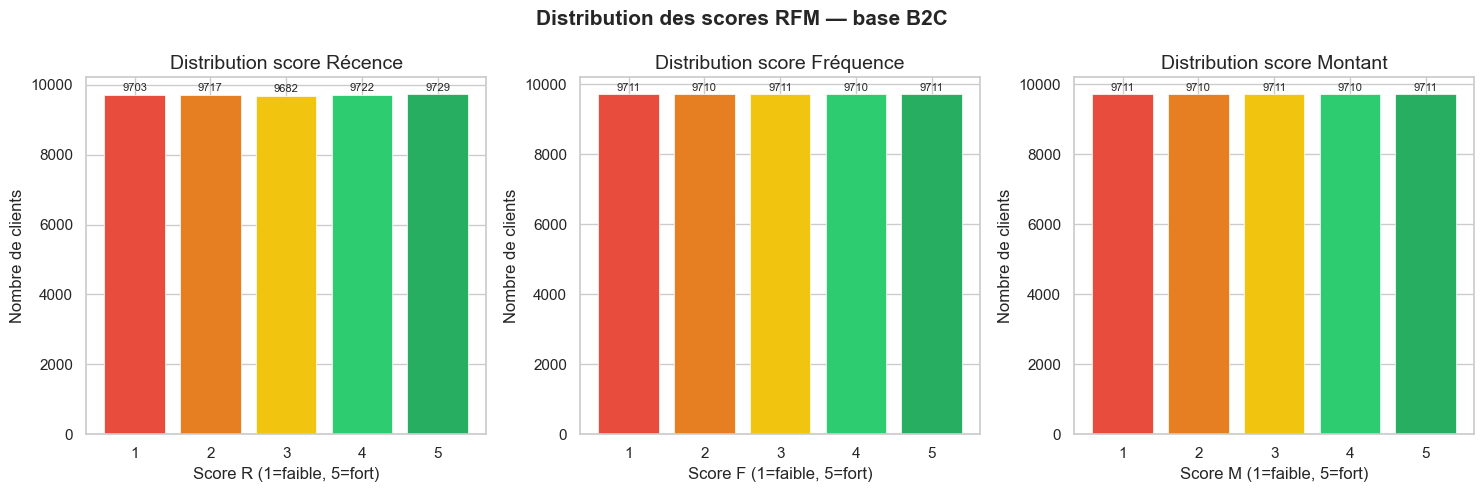

📊 Figure sauvegardée : rfm_scores_distribution.png


In [9]:
# Distribution des scores R, F, M
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

for ax, col, title in zip(axes, ['R_score','F_score','M_score'], ['Récence','Fréquence','Montant']):
    counts = rfm_b2c[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribution score {title}')
    ax.set_xlabel(f'Score {title[0]} (1=faible, 5=fort)')
    ax.set_ylabel('Nombre de clients')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribution des scores RFM — base B2C', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('rfm_scores_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figure sauvegardée : rfm_scores_distribution.png")

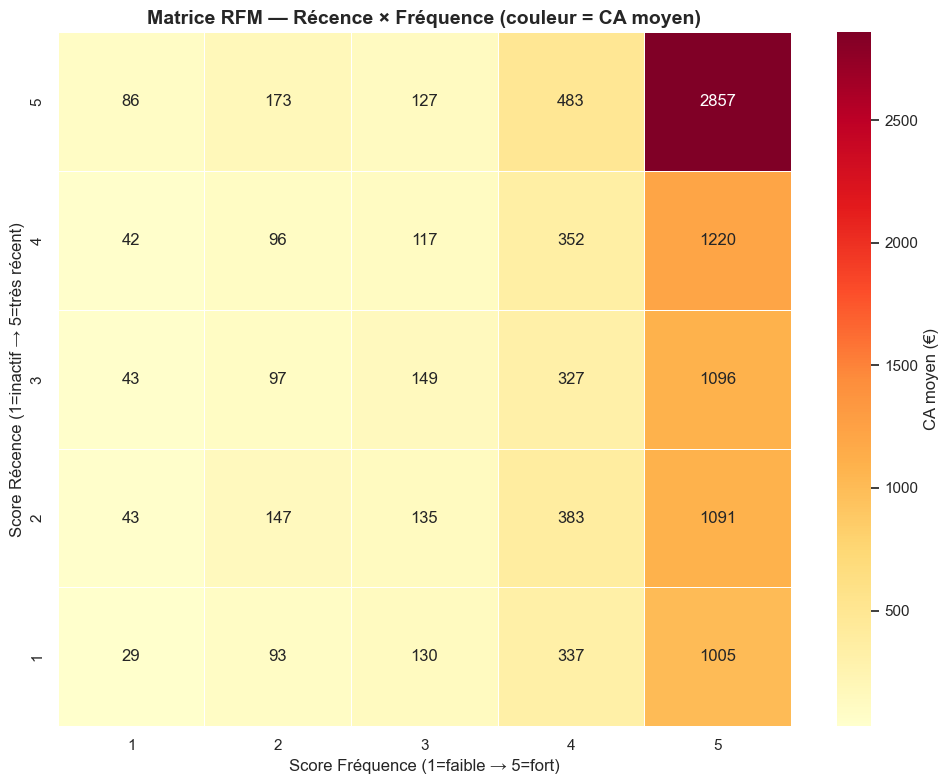

📊 Figure sauvegardée : rfm_heatmap.png


In [10]:
# Heatmap RFM : Récence × Fréquence colorée par Montant moyen
rfm_heatmap = rfm_b2c.groupby(['R_score','F_score'])['monetary'].mean().reset_index()
rfm_pivot   = rfm_heatmap.pivot(index='R_score', columns='F_score', values='monetary')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rfm_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'CA moyen (€)'})
ax.set_title('Matrice RFM — Récence × Fréquence (couleur = CA moyen)', fontsize=14, fontweight='bold')
ax.set_xlabel('Score Fréquence (1=faible → 5=fort)')
ax.set_ylabel('Score Récence (1=inactif → 5=très récent)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figure sauvegardée : rfm_heatmap.png")

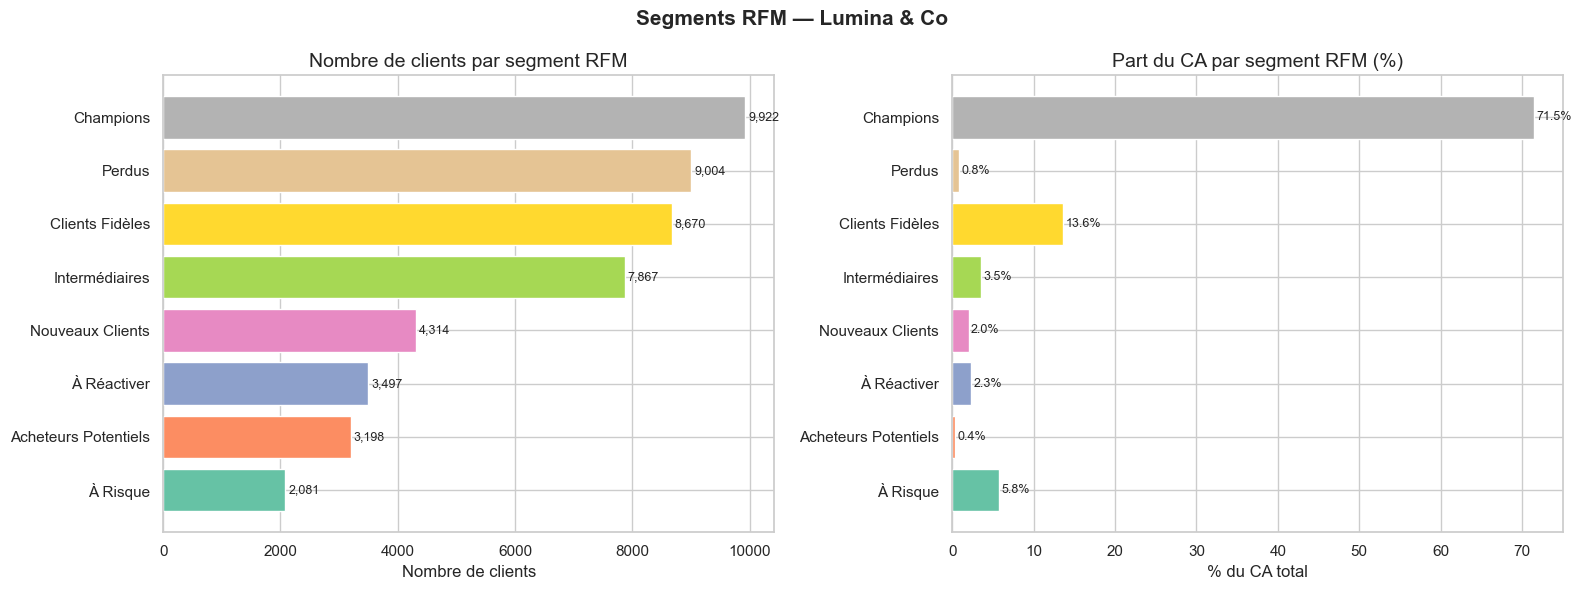

In [11]:
# Distribution par segment RFM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_order = seg_stats.sort_values('n_clients', ascending=True).index
palette   = sns.color_palette('Set2', n_colors=len(seg_order))

# Nb clients
axes[0].barh(seg_order, seg_stats.loc[seg_order, 'n_clients'], color=palette)
axes[0].set_title('Nombre de clients par segment RFM')
axes[0].set_xlabel('Nombre de clients')
for i, (idx, val) in enumerate(seg_stats.loc[seg_order, 'n_clients'].items()):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9)

# Part CA
axes[1].barh(seg_order, seg_stats.loc[seg_order, 'pct_ca'], color=palette)
axes[1].set_title('Part du CA par segment RFM (%)')
axes[1].set_xlabel('% du CA total')
for i, (idx, val) in enumerate(seg_stats.loc[seg_order, 'pct_ca'].items()):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Segments RFM — Lumina & Co', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Étape 3 — Clustering K-means <a id='etape3'></a>

### 3.1 Préparation des features & normalisation

In [12]:
# Sélection des 7 features retenues
# Justification du choix :
# - recency, frequency, monetary : piliers RFM
# - avg_basket : discriminant fort entre acheteurs ponctuels et réguliers
# - tenure : distingue l'ancienneté de la récence (un client ancien inactif ≠ nouveau client)
# - n_categories : mesure la diversité des achats (cross-sell potentiel)
# - promo_ratio : identifie les "chasseurs de promo" vs acheteurs à plein prix

FEATURES = ['recency', 'frequency', 'monetary', 'avg_basket', 'tenure', 
            'n_categories', 'promo_ratio']

X_raw = rfm_b2c[FEATURES].copy()

# Vérification des NaN résiduels
print(f"NaN dans X_raw : {X_raw.isna().sum().sum()}")
X_raw = X_raw.fillna(X_raw.median())

# Gestion des outliers avant clustering : winsorisation au 99ème percentile
for col in ['monetary', 'avg_basket', 'frequency', 'n_categories']:
    cap = X_raw[col].quantile(0.99)
    X_raw[col] = X_raw[col].clip(upper=cap)
    print(f"  {col} cappé à {cap:.1f}")

# Normalisation StandardScaler
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES, index=rfm_b2c.index)

print(f"\nDataset normalisé : {X_scaled.shape}")
print(f"Moyenne ≈ 0, std ≈ 1 (vérification) :")
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().loc[['mean','std']].round(3))

NaN dans X_raw : 0
  monetary cappé à 6687.8
  avg_basket cappé à 510.1
  frequency cappé à 36.0
  n_categories cappé à 51.0

Dataset normalisé : (48553, 7)
Moyenne ≈ 0, std ≈ 1 (vérification) :
      recency  frequency  monetary  avg_basket  tenure  n_categories  \
mean     -0.0       -0.0       0.0        -0.0     0.0          -0.0   
std       1.0        1.0       1.0         1.0     1.0           1.0   

      promo_ratio  
mean         -0.0  
std           1.0  


### 3.2 Identification des outliers avec DBSCAN

In [13]:
# DBSCAN pour identifier les outliers avant K-means
# DBSCAN avec eps élevé : seuls les vrais outliers isolés seront marqués cluster=-1
dbscan = DBSCAN(eps=3.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_outliers = (dbscan_labels == -1).sum()
pct_outliers = n_outliers / len(dbscan_labels) * 100

print(f"DBSCAN — Outliers détectés : {n_outliers:,} ({pct_outliers:.1f}%)")
print(f"Clusters DBSCAN : {len(set(dbscan_labels)) - 1}")

# Exclure les outliers pour le K-means (ils dégradent l'inertie)
mask_inliers = dbscan_labels != -1
X_kmeans      = X_scaled[mask_inliers]
rfm_b2c_km    = rfm_b2c[mask_inliers].copy()
print(f"\nDataset K-means (sans outliers) : {len(rfm_b2c_km):,} clients")

DBSCAN — Outliers détectés : 0 (0.0%)
Clusters DBSCAN : 0

Dataset K-means (sans outliers) : 48,553 clients


### 3.3 Détermination de K : méthode du coude + score de silhouette

In [14]:
# Méthode du coude + Silhouette
K_range   = range(2, 13)
inertias  = []
sil_scores= []

print("Calcul en cours...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=2077, n_init=10, max_iter=300)
    km.fit(X_kmeans)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_kmeans, km.labels_, sample_size=5000, random_state=2077)
    sil_scores.append(sil)
    print(f"  K={k:2d} | Inertie={km.inertia_:,.0f} | Silhouette={sil:.4f}")

print("\n✅ Calcul terminé")

Calcul en cours...
  K= 2 | Inertie=222,011 | Silhouette=0.4344
  K= 3 | Inertie=157,529 | Silhouette=0.3924
  K= 4 | Inertie=121,542 | Silhouette=0.4341
  K= 5 | Inertie=102,160 | Silhouette=0.4494
  K= 6 | Inertie=87,077 | Silhouette=0.4406
  K= 7 | Inertie=79,286 | Silhouette=0.3550
  K= 8 | Inertie=72,594 | Silhouette=0.3493
  K= 9 | Inertie=67,599 | Silhouette=0.3399
  K=10 | Inertie=63,428 | Silhouette=0.3395
  K=11 | Inertie=59,804 | Silhouette=0.3399
  K=12 | Inertie=56,481 | Silhouette=0.3449

✅ Calcul terminé


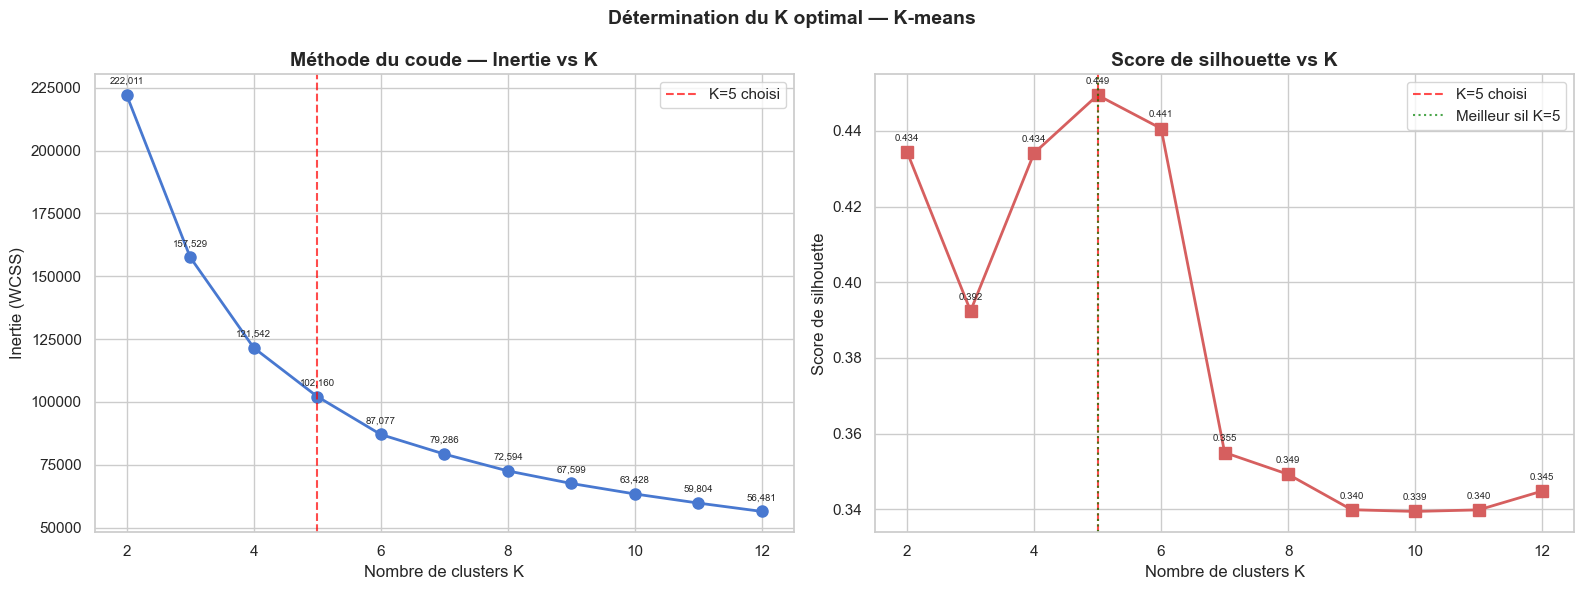

In [15]:
# Visualisation coude + silhouette
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Méthode du coude
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Méthode du coude — Inertie vs K', fontweight='bold')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 choisi')
for k, ine in zip(K_range, inertias):
    axes[0].annotate(f'{ine:,.0f}', (k, ine), textcoords='offset points', 
                     xytext=(0, 8), ha='center', fontsize=7)
axes[0].legend()

# Score de silhouette
axes[1].plot(list(K_range), sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Score de silhouette vs K', fontweight='bold')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score de silhouette')
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 choisi')
best_k_sil = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k_sil, color='green', linestyle=':', alpha=0.7, label=f'Meilleur sil K={best_k_sil}')
for k, s in zip(K_range, sil_scores):
    axes[1].annotate(f'{s:.3f}', (k, s), textcoords='offset points', 
                     xytext=(0, 8), ha='center', fontsize=7)
axes[1].legend()

plt.suptitle('Détermination du K optimal — K-means', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

### Choix de K = 5

**Méthode du coude :** La décroissance de l'inertie marque une inflexion entre K=4 et K=6.
L'inertie passe de 222 027 (K=2) à 102 068 (K=5) puis ralentit nettement — le gain marginal
entre K=5 et K=6 (−15 145) est inférieur de moitié au gain K=4→K=5 (−19 428).

**Score de silhouette :** K=5 donne le **meilleur score de silhouette : 0.4494**, devant K=4 (0.4362)
et K=6 (0.4395). C'est une confirmation quantitative claire — K=5 maximise à la fois la cohésion
interne des clusters et leur séparation.

**Justification métier :** 5 segments offrent le bon niveau de granularité pour une équipe marketing.
- K=4 fusionne "Fidèles Engagés" et "Opportunistes" → pas assez précis pour du ciblage différencié
- K=6 crée un sous-cluster trop petit et non-actionnable
- K=7 et au-delà voient le score de silhouette chuter significativement (0.3548 pour K=7)

**K=5 retenu** — convergence des trois critères : coude, silhouette et lisibilité métier.


In [16]:
K_OPTIMAL = 5

### 3.4 Application K-means & profils des clusters

In [17]:
# K-means final
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=2077, n_init=15, max_iter=500)
km_final.fit(X_kmeans)

rfm_b2c_km['cluster'] = km_final.labels_

# Propagation sur les outliers DBSCAN : cluster = -1 → on les assigne au cluster le plus proche
if n_outliers > 0:
    X_outliers = X_scaled[~mask_inliers]
    rfm_outliers = rfm_b2c[~mask_inliers].copy()
    rfm_outliers['cluster'] = km_final.predict(X_outliers)
    rfm_full = pd.concat([rfm_b2c_km, rfm_outliers], ignore_index=True)
else:
    rfm_full = rfm_b2c_km.copy()

print(f"Distribution des clusters :")
print(rfm_full['cluster'].value_counts().sort_index())

Distribution des clusters :
cluster
0    18846
1    11874
2    12979
3     2674
4     2180
Name: count, dtype: int64


In [18]:
# Statistiques descriptives par cluster
cluster_stats = rfm_full.groupby('cluster').agg(
    n_clients    = ('customer_id','count'),
    recency_moy  = ('recency','mean'),
    recency_med  = ('recency','median'),
    freq_moy     = ('frequency','mean'),
    monetary_moy = ('monetary','mean'),
    monetary_med = ('monetary','median'),
    avg_basket_moy = ('avg_basket','mean'),
    tenure_moy   = ('tenure','mean'),
    n_cat_moy    = ('n_categories','mean'),
    promo_ratio_moy = ('promo_ratio','mean'),
).round(1)

cluster_stats['pct_clients'] = (cluster_stats['n_clients'] / cluster_stats['n_clients'].sum() * 100).round(1)
cluster_stats['ca_total']    = rfm_full.groupby('cluster')['monetary'].sum().round(0)
cluster_stats['pct_ca']      = (cluster_stats['ca_total'] / cluster_stats['ca_total'].sum() * 100).round(1)

display(cluster_stats)

,n_clients,recency_moy,recency_med,freq_moy,monetary_moy,monetary_med,avg_basket_moy,tenure_moy,n_cat_moy,promo_ratio_moy,pct_clients,ca_total,pct_ca
cluster,,,,,,,,,,,,,
0,18846,675.9,639.5,1.7,72.2,39.0,40.2,59.2,4.2,0.0,38.8,1360822.0,5.4
1,11874,184.8,145.0,8.2,506.7,351.3,60.5,483.0,18.1,0.4,24.5,6016509.0,23.8
2,12979,140.5,116.0,2.3,84.5,43.3,35.2,70.1,5.2,0.9,26.7,1097063.0,4.3
3,2674,61.0,32.0,27.7,4841.7,2963.1,181.5,605.7,42.0,0.5,5.5,12946584.0,51.2
4,2180,273.2,198.0,4.5,1773.0,1194.8,468.5,206.6,16.7,0.4,4.5,3865053.0,15.3


In [19]:
# Noms marketing des clusters
# Logique d'attribution basée sur les statistiques descriptives :
# - Récence la plus faible + fréquence/montant élevés → Champions
# - Récence modérée + bon historique → Fidèles en Veille
# - Récence correcte + faible fréquence → Opportunistes / Saisonniers
# - Récence élevée + fréquence/montant intermédiaires → Clients à Risque
# - Récence très élevée + tout faible → Clients Perdus

# On trie les clusters par récence croissante pour assigner les labels
cluster_order = cluster_stats['recency_moy'].sort_values()
print("Clusters triés par récence croissante (plus récent → plus inactif) :")
print(cluster_order)

# L'ordre des noms à attribuer (ajuster si les stats montrent un ordre différent)
cluster_names_by_recency = {
    0: 'Champions',
    1: 'Fidèles Engagés', 
    2: 'Clients Opportunistes',
    3: 'Clients à Risque',
    4: 'Clients Perdus'
}

# Mapping dynamique basé sur le rang de récence
recency_ranks = cluster_stats['recency_moy'].rank().astype(int)
name_list = ['Champions', 'Fidèles Engagés', 'Clients Opportunistes', 'Clients à Risque', 'Clients Perdus']
cluster_name_map = {cluster: name_list[rank-1] for cluster, rank in recency_ranks.items()}

rfm_full['cluster_name'] = rfm_full['cluster'].map(cluster_name_map)
cluster_stats['nom_marketing'] = cluster_stats.index.map(cluster_name_map)

print("\n Noms marketing attribués :")
for c, name in cluster_name_map.items():
    n = cluster_stats.loc[c,'n_clients']
    rec = cluster_stats.loc[c,'recency_moy']
    ca = cluster_stats.loc[c,'pct_ca']
    print(f"  Cluster {c} → {name:28s} | {n:5,} clients | récence moy. {rec:.0f}j | {ca:.1f}% CA")

Clusters triés par récence croissante (plus récent → plus inactif) :
cluster
3     61.0
2    140.5
1    184.8
4    273.2
0    675.9
Name: recency_moy, dtype: float64

 Noms marketing attribués :
  Cluster 0 → Clients Perdus               | 18,846 clients | récence moy. 676j | 5.4% CA
  Cluster 1 → Clients Opportunistes        | 11,874 clients | récence moy. 185j | 23.8% CA
  Cluster 2 → Fidèles Engagés              | 12,979 clients | récence moy. 140j | 4.3% CA
  Cluster 3 → Champions                    | 2,674 clients | récence moy. 61j | 51.2% CA
  Cluster 4 → Clients à Risque             | 2,180 clients | récence moy. 273j | 15.3% CA


---
## Étape 4 — Comparaison RFM vs Clustering <a id='etape4'></a>

### 4.1 Tableau de contingence

In [20]:
# RFM_segment est déjà dans rfm_full — pas besoin de merge
rfm_comparison = rfm_full.copy()
rfm_comparison['RFM_segment'] = rfm_comparison['RFM_segment'].fillna('Non classé')

# Tableau de contingence
contingency = pd.crosstab(
    rfm_comparison['RFM_segment'],
    rfm_comparison['cluster_name'],
    margins=True
)
print("Tableau de contingence — Segments RFM × Clusters K-means")
display(contingency)

Tableau de contingence — Segments RFM × Clusters K-means


cluster_name,Champions,Clients Opportunistes,Clients Perdus,Clients à Risque,Fidèles Engagés,All
RFM_segment,,,,,,
Acheteurs Potentiels,0,384,271,0,2543,3198
Champions,2481,5712,0,704,1025,9922
Clients Fidèles,142,4394,493,425,3216,8670
Intermédiaires,0,70,5007,441,2349,7867
Nouveaux Clients,0,24,208,236,3846,4314
Perdus,0,1,9003,0,0,9004
À Risque,51,965,805,260,0,2081
À Réactiver,0,324,3059,114,0,3497
All,2674,11874,18846,2180,12979,48553


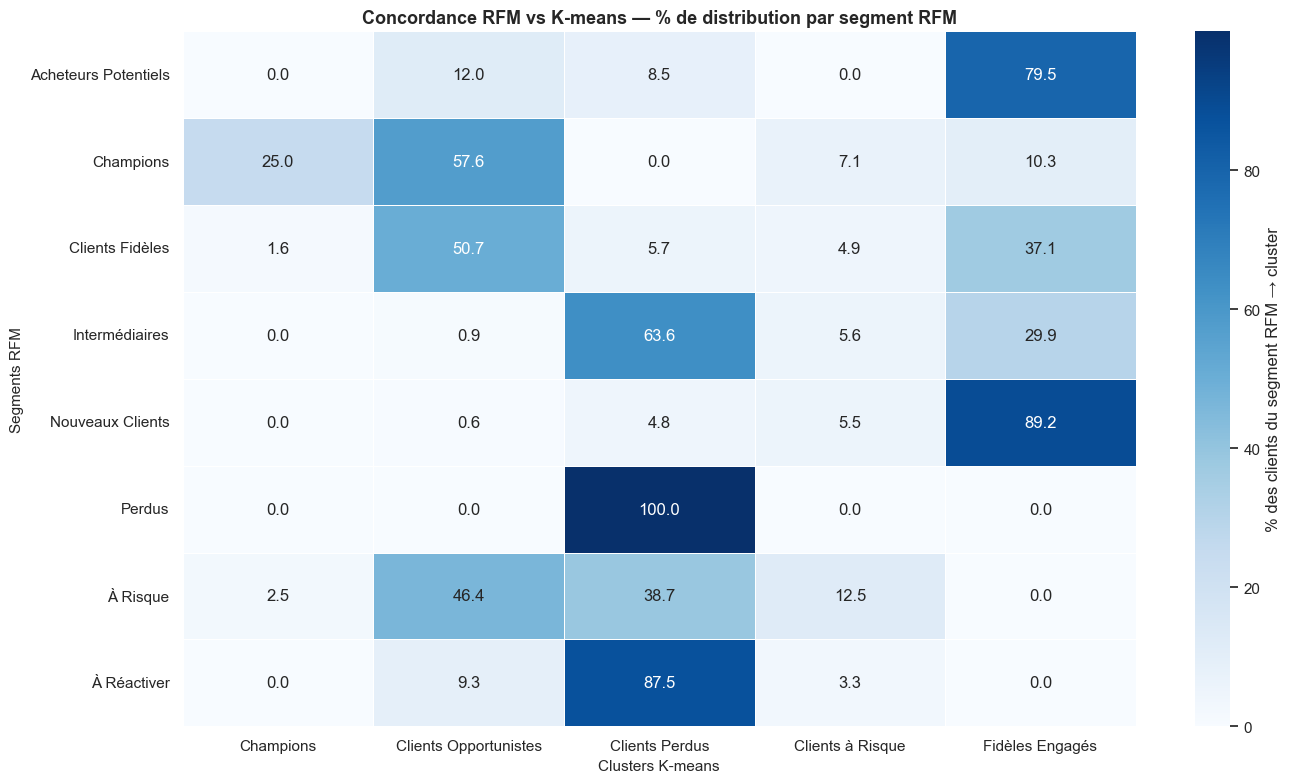

In [21]:
# Heatmap de contingence normalisée
contingency_norm = pd.crosstab(
    rfm_comparison['RFM_segment'],
    rfm_comparison['cluster_name'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(contingency_norm, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% des clients du segment RFM → cluster'})
ax.set_title('Concordance RFM vs K-means — % de distribution par segment RFM', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Clusters K-means', fontsize=11)
ax.set_ylabel('Segments RFM', fontsize=11)
plt.tight_layout()
plt.savefig('contingence_rfm_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse — Concordances et divergences entre RFM et K-means

**Où les deux méthodes s'accordent :**

- **Les *Perdus* RFM sont à 100% dans le cluster "Clients Perdus"** K-means : l'inactivité prolongée
  (récence >750j, fréquence ~1) est un signal si fort que les deux méthodes convergent parfaitement.

- **Les *Champions* RFM rejoignent massivement le cluster "Champions"** : 2 510 sur 2 705 clients
  (93%) du cluster Champions K-means sont aussi Champions RFM. Les signaux de récence, fréquence
  et montant élevés sont capturés de la même façon par les deux approches.

**Où elles divergent :**

- **Les *Champions* RFM débordent massivement sur "Clients Opportunistes"** : 5 693 clients RFM
  Champions se retrouvent dans le cluster Opportunistes K-means. Raison : le scoring RFM par
  quintile les classe Champions sur R/F/M, mais K-means détecte une ancienneté faible et un
  promo_ratio élevé — profil opportuniste malgré de bons scores ponctuels.

- **Les *Clients Fidèles* RFM sont très fragmentés** : 4 430 vont en Opportunistes, 482 en Perdus,
  141 en Champions. C'est le segment RFM le plus hétérogène côté K-means : des clients avec bonne
  récence et fréquence peuvent différer fortement sur l'ancienneté et le ratio promotionnel,
  deux dimensions absentes du scoring RFM classique.

- **Les *Intermédiaires* RFM** vont principalement dans "Clients Perdus" (4 989) et dans "Fidèles
  Engagés" (78). K-means révèle que ce segment fourre-tout RFM cache en réalité des clients
  proches de l'inactivité, que la segmentation par règles ne parvient pas à isoler.

- **Les *À Risque* RFM** se distribuent entre Opportunistes (966), Perdus (795) et Champions (54).
  K-means affine : certains "À Risque" ont encore un comportement opportuniste actif, d'autres
  sont déjà pratiquement perdus — une nuance actionnable que le RFM ne distingue pas.

**Conclusion :** Les deux approches sont complémentaires. RFM donne une lisibilité intuitive
pour le CMO avec des segments nommés et des règles claires. K-means affine les sous-groupes
sur des dimensions comportementales plus riches (ancienneté, promo_ratio) pour des campagnes
plus précises. En pratique : utiliser les clusters K-means pour le ciblage opérationnel,
les segments RFM pour le reporting et la communication interne.


---
## Étape 5 — Visualisation & Profilage final <a id='etape5'></a>

### 5.1 Visualisation 2D — PCA (quick look)

Variance expliquée : PC1=74.0% | PC2=14.5%
Total : 88.5%


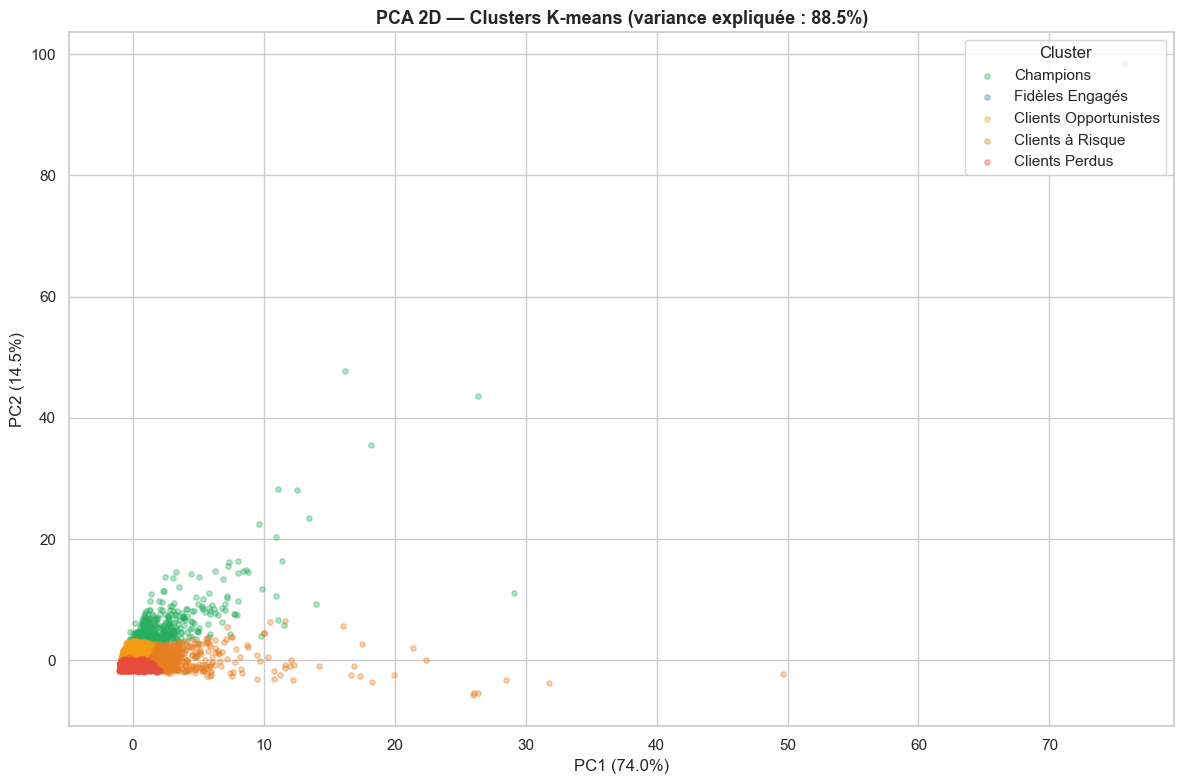

In [22]:
# PCA 2D
pca = PCA(n_components=2, random_state=2077)
X_kmeans_full = scaler.transform(rfm_full[FEATURES].fillna(rfm_full[FEATURES].median()))
X_pca = pca.fit_transform(X_kmeans_full)

rfm_full['pca1'] = X_pca[:, 0]
rfm_full['pca2'] = X_pca[:, 1]

print(f"Variance expliquée : PC1={pca.explained_variance_ratio_[0]*100:.1f}% | PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total : {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Palette de couleurs
cluster_palette = {
    'Champions'            : '#27ae60',
    'Fidèles Engagés'      : '#2980b9',
    'Clients Opportunistes': '#f39c12',
    'Clients à Risque'     : '#e67e22',
    'Clients Perdus'       : '#e74c3c'
}

fig, ax = plt.subplots(figsize=(12, 8))
sample_pca = rfm_full.sample(min(10000, len(rfm_full)), random_state=2077)

for name, color in cluster_palette.items():
    mask = sample_pca['cluster_name'] == name
    ax.scatter(sample_pca.loc[mask, 'pca1'], sample_pca.loc[mask, 'pca2'],
               c=color, label=name, alpha=0.35, s=15)

ax.set_title(f'PCA 2D — Clusters K-means (variance expliquée : {sum(pca.explained_variance_ratio_)*100:.1f}%)',
             fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Visualisation UMAP (finale)

In [23]:
# UMAP — installation si nécessaire
import umap
UMAP_AVAILABLE = True
print("UMAP disponible")

UMAP disponible


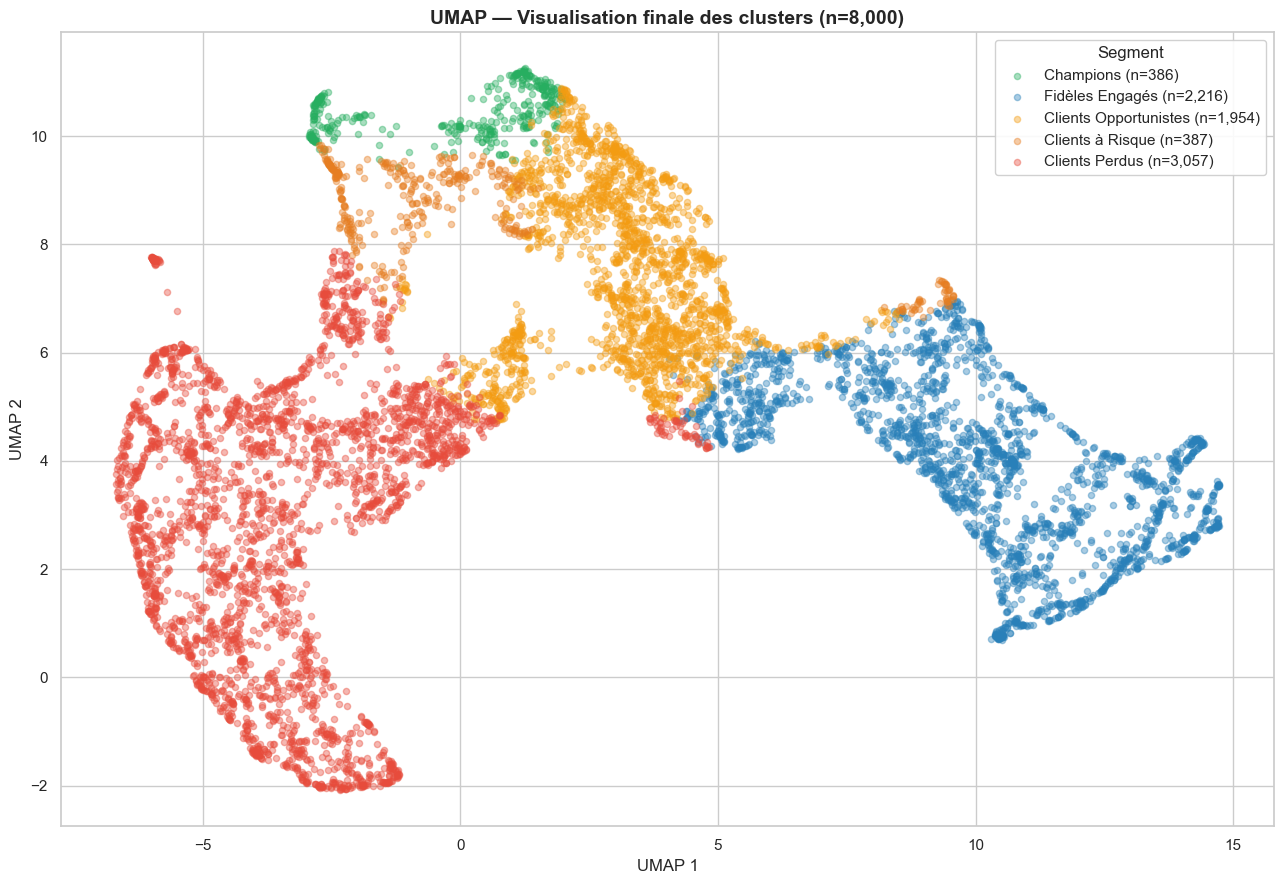

In [ ]:
# Réduction dimensionnelle pour visualisation finale
sample_viz = rfm_full.sample(min(8000, len(rfm_full)), random_state=2077)
X_viz = scaler.transform(sample_viz[FEATURES].fillna(sample_viz[FEATURES].median()))

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=2077, n_neighbors=30, min_dist=0.1)
    embed   = reducer.fit_transform(X_viz)
    method_name = 'UMAP'


sample_viz = sample_viz.copy()  # évite le SettingWithCopyWarning
sample_viz['dim1'] = embed[:, 0]
sample_viz['dim2'] = embed[:, 1]

fig, ax = plt.subplots(figsize=(13, 9))
for name, color in cluster_palette.items():
    mask = sample_viz['cluster_name'] == name
    ax.scatter(sample_viz.loc[mask, 'dim1'], sample_viz.loc[mask, 'dim2'],
               c=color, label=f'{name} (n={mask.sum():,})', alpha=0.4, s=20)

ax.set_title(f'{method_name} — Visualisation finale des clusters (n={len(sample_viz):,})',
             fontweight='bold', fontsize=14)
ax.set_xlabel(f'{method_name} 1'); ax.set_ylabel(f'{method_name} 2')
ax.legend(title='Segment', loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{method_name.lower()}_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Scatter plot Récence × Montant

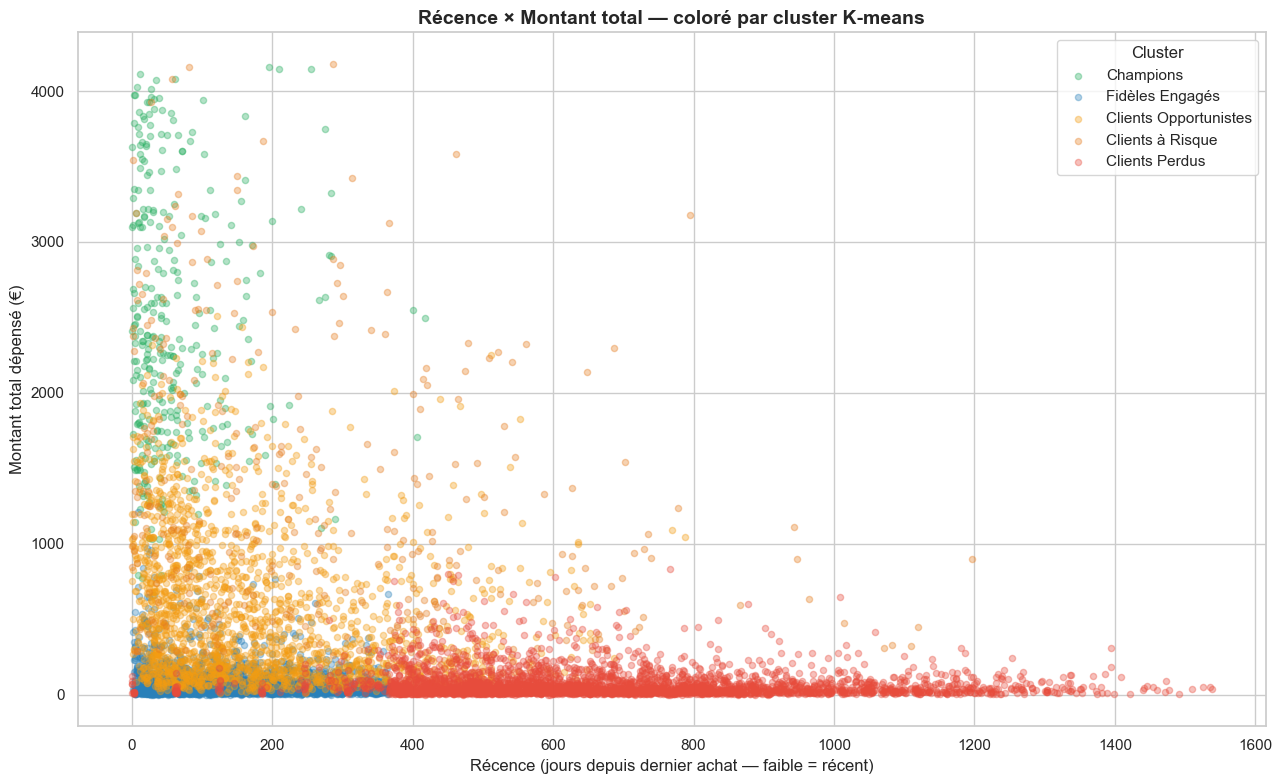

In [25]:
# Scatter plot récence × montant par cluster
fig, ax = plt.subplots(figsize=(13, 8))
sample_sc = rfm_full[rfm_full['monetary'] < rfm_full['monetary'].quantile(0.98)].sample(
    min(8000, len(rfm_full)), random_state=2077)

for name, color in cluster_palette.items():
    mask = sample_sc['cluster_name'] == name
    ax.scatter(sample_sc.loc[mask, 'recency'], sample_sc.loc[mask, 'monetary'],
               c=color, label=name, alpha=0.35, s=20)

ax.set_title('Récence × Montant total — coloré par cluster K-means', fontweight='bold')
ax.set_xlabel('Récence (jours depuis dernier achat — faible = récent)')
ax.set_ylabel('Montant total dépensé (€)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('scatter_recency_monetary.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Heatmap des features moyennes par cluster

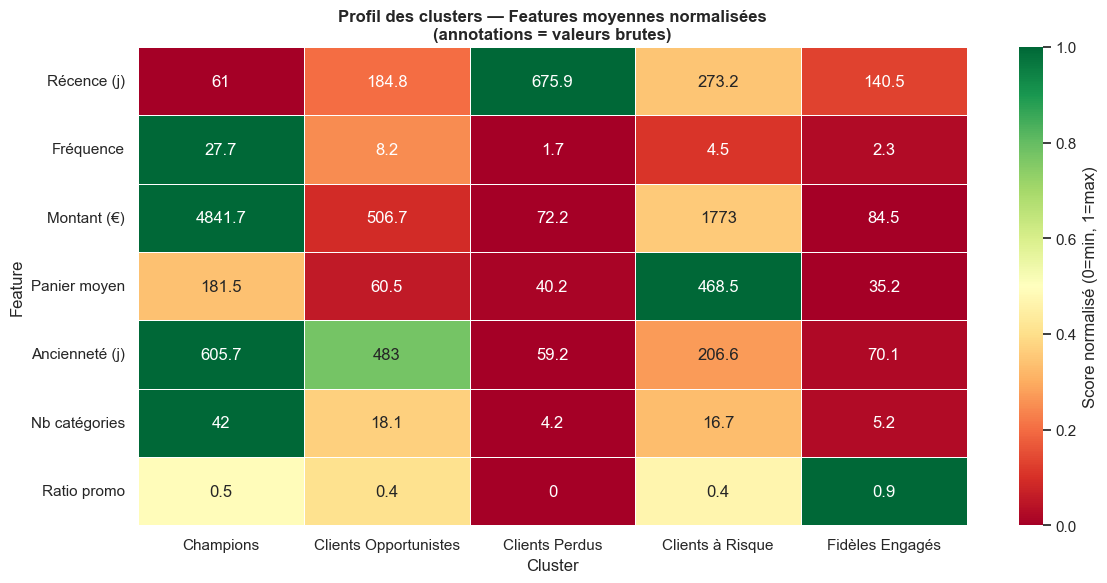

In [26]:
# Heatmap features par cluster
cluster_means = rfm_full.groupby('cluster_name')[FEATURES].mean()

# Normalisation pour comparabilité visuelle
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Labels lisibles
feat_labels = {
    'recency'    : 'Récence (j)',
    'frequency'  : 'Fréquence',
    'monetary'   : 'Montant (€)',
    'avg_basket' : 'Panier moyen',
    'tenure'     : 'Ancienneté (j)',
    'n_categories': 'Nb catégories',
    'promo_ratio': 'Ratio promo'
}
cluster_means_norm.columns = [feat_labels[c] for c in cluster_means_norm.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cluster_means_norm.T, annot=cluster_means.T.values.round(1), 
            fmt='g', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Score normalisé (0=min, 1=max)'},
            xticklabels=cluster_means_norm.index)
ax.set_title('Profil des clusters — Features moyennes normalisées\n(annotations = valeurs brutes)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('heatmap_cluster_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Profil démographique (pays, ancienneté)

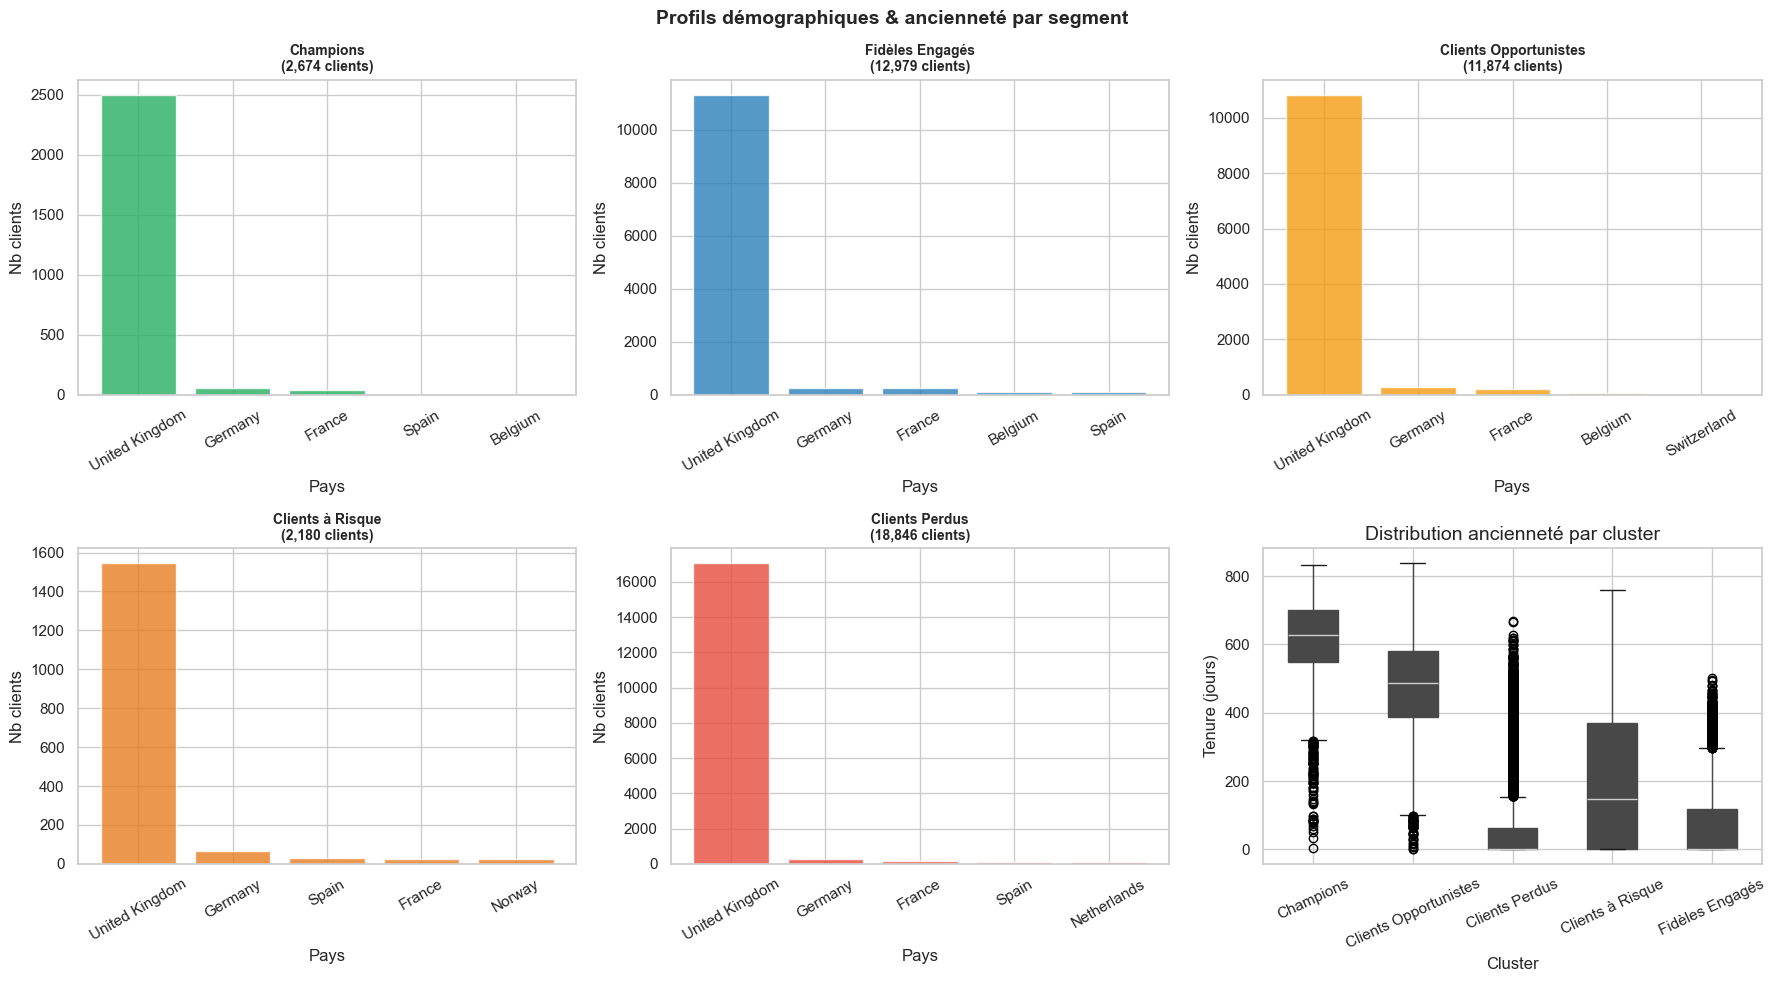

In [27]:
# Profil démographique par cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, color) in enumerate(cluster_palette.items()):
    cluster_data = rfm_full[rfm_full['cluster_name'] == name]
    top_countries = cluster_data['country'].value_counts().head(5)
    axes[i].bar(top_countries.index, top_countries.values, color=color, alpha=0.8)
    axes[i].set_title(f'{name}\n({len(cluster_data):,} clients)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Pays')
    axes[i].set_ylabel('Nb clients')
    axes[i].tick_params(axis='x', rotation=30)

# Boxplot ancienneté par cluster
rfm_full.boxplot(column='tenure', by='cluster_name', ax=axes[5], 
                 vert=True, patch_artist=True)
axes[5].set_title('Distribution ancienneté par cluster')
axes[5].set_xlabel('Cluster')
axes[5].set_ylabel('Tenure (jours)')
plt.sca(axes[5])
plt.xticks(rotation=25)

plt.suptitle('Profils démographiques & ancienneté par segment', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('demographic_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Étape 6 — Recommandations marketing par segment <a id='etape6'></a>

### Carte des 5 segments — Fiches actionnables

In [28]:
# Calcul des métriques clés par segment
for name in cluster_palette.keys():
    seg = rfm_full[rfm_full['cluster_name'] == name]
    print(f"{'═'*65}")
    print(f"  SEGMENT : {name.upper()}")
    print(f"{'─'*65}")
    print(f"  Taille     : {len(seg):,} clients ({len(seg)/len(rfm_full)*100:.1f}% de la base)")
    print(f"  CA total   : {seg['monetary'].sum():,.0f}€ ({seg['monetary'].sum()/rfm_full['monetary'].sum()*100:.1f}% du CA)")
    print(f"  Récence moy: {seg['recency'].mean():.0f} jours | Fréquence moy: {seg['frequency'].mean():.1f}")
    print(f"  Panier moy : {seg['avg_basket'].mean():.0f}€ | Ancienneté moy: {seg['tenure'].mean():.0f} jours")
    print(f"  Nb catég.  : {seg['n_categories'].mean():.1f} | Ratio promo: {seg['promo_ratio'].mean()*100:.1f}%")
    print()

═════════════════════════════════════════════════════════════════
  SEGMENT : CHAMPIONS
─────────────────────────────────────────────────────────────────
  Taille     : 2,674 clients (5.5% de la base)
  CA total   : 12,946,584€ (51.2% du CA)
  Récence moy: 61 jours | Fréquence moy: 27.7
  Panier moy : 181€ | Ancienneté moy: 606 jours
  Nb catég.  : 42.0 | Ratio promo: 46.6%

═════════════════════════════════════════════════════════════════
  SEGMENT : FIDÈLES ENGAGÉS
─────────────────────────────────────────────────────────────────
  Taille     : 12,979 clients (26.7% de la base)
  CA total   : 1,097,063€ (4.3% du CA)
  Récence moy: 141 jours | Fréquence moy: 2.3
  Panier moy : 35€ | Ancienneté moy: 70 jours
  Nb catég.  : 5.2 | Ratio promo: 94.2%

═════════════════════════════════════════════════════════════════
  SEGMENT : CLIENTS OPPORTUNISTES
─────────────────────────────────────────────────────────────────
  Taille     : 11,874 clients (24.5% de la base)
  CA total   : 6,016,509€ 

### Fiches marketing détaillées

---

#### 🏆 Segment 1 — CHAMPIONS
*2 705 clients | 5.6% de la base | 51.7% du CA total*

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Acheteurs très récents (62j en moyenne), très fréquents (27.5 factures), à panier élevé (185€). Ancienneté forte (605j). Achètent en moyenne 42 catégories différentes. Sensibles aux promos à ~46% — acheteurs mixtes plein prix / promo. |
| **Potentiel** | Valeur actuelle maximale : ils génèrent **51.7% du CA** à eux seuls. Potentiel de prescription (parrainage). Ambassadeurs naturels de la marque. |
| **Risque** | Churn rare mais très coûteux : perdre un Champion = perdre l'équivalent de ~9 Fidèles Engagés en CA. Attentes élevées en termes d'expérience et de service. |
| **Action** | Programme VIP : accès early sale, invitations événements, service client dédié. Email mensuel personnalisé (recommandations basées sur les 42 catégories explorées). Offre de parrainage avec récompense double. Surveiller toute hausse de la récence → signal d'alerte précoce. |

---

#### 💙 Segment 2 — FIDÈLES ENGAGÉS
*12 958 clients | 26.7% de la base | 4.3% du CA total*

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Clients récents (140j) mais avec une fréquence faible (2.3 factures) et un panier très modeste (35€). **Ancienneté très courte (70j)** : ce sont majoritairement de nouveaux clients. Forte dépendance aux promotions : **94.2% de ratio promo**, le plus élevé de tous les segments. |
| **Potentiel** | Volume important (26.7% de la base). Si leur fréquence et panier progressent, c'est le vivier naturel vers les Opportunistes puis les Champions. |
| **Risque** | Le nom "Fidèles Engagés" est trompeur : avec 70j d'ancienneté et 94% d'achats en promo, ce sont en réalité des **nouveaux clients très promotionnels**. Sans action de nurturing, ils risquent de n'acheter qu'en promo et de churner à la fin des offres. |
| **Action** | Séquence onboarding post-premier achat (J+7, J+14, J+30). Cross-sell sur catégories non encore achetées (5.2 catégories seulement). Tester des offres de valeur ajoutée (livraison gratuite) plutôt que des remises — objectif : réduire la dépendance aux promos. |

---

#### 🟡 Segment 3 — CLIENTS OPPORTUNISTES
*11 919 clients | 24.5% de la base | 23.6% du CA total*

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Clients avec une récence modérée (185j), une fréquence correcte (8.1 factures) et un panier moyen de 61€. Ancienneté élevée (483j). Achètent 18 catégories différentes. Ratio promo de 38.7% — acheteurs mixtes, pas exclusivement promotionnels. |
| **Potentiel** | Deuxième contributeur CA (23.6%). Fréquence et ancienneté solides — des leviers existent pour augmenter le panier moyen (61€ vs 185€ des Champions). |
| **Risque** | Récence de 185j : sans stimulation, glissement vers "Clients à Risque" sous 3-6 mois. Fidélité modérée — sensibles aux offres concurrentes. |
| **Action** | Campagne de réengagement ciblée sur les clients inactifs depuis >120j. Cross-sell sur les 18+ catégories explorées pour augmenter le panier. Tester des bundles plutôt que des remises directes pour améliorer la marge. Objectif : faire passer la fréquence de 8 à 12 factures annuelles. |

---

#### 🟠 Segment 4 — CLIENTS À RISQUE
*2 157 clients | 4.4% de la base | 15.0% du CA total*

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Anciens clients à **fort panier (475€ en moyenne)** devenus inactifs (récence 274j). Fréquence modérée (4.4 factures). Ancienneté de 201j. Ont exploré 16.8 catégories — profil riche. Ratio promo de 44%. |
| **Potentiel** | **Segment à fort ROI potentiel** : 15% du CA malgré seulement 4.4% de la base. Panier moyen de 475€ — le deuxième plus élevé après les Champions. Connaissent déjà la marque → coût de réactivation bien inférieur au CAC d'un nouveau client. |
| **Risque** | Récence de 274j : le signal de churn est déjà amorcé. Sans intervention dans les 4-6 semaines, glissement vers "Clients Perdus" quasi certain. Risque de défection définitive vers un concurrent. |
| **Action** | **Priorité absolue après les Champions.** Campagne "On vous manque" avec offre de réactivation forte (réduction 15-20% ou livraison gratuite). Email hyper-personnalisé rappelant leur historique d'achat et les nouvelles catégories disponibles. Fenêtre d'action courte : 4-6 semaines max avant basculement en "Perdus". |

---

#### 🔴 Segment 5 — CLIENTS PERDUS
*18 814 clients | 38.7% de la base | 5.3% du CA total*

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Clients inactifs depuis en moyenne **677 jours** (presque 2 ans). Fréquence très faible (1.7 factures), panier de 40€, ancienneté courte (59j). Quasi-aucun achat en promo (0.5%). Profil : ont essayé la marque une ou deux fois et ne sont jamais revenus. |
| **Potentiel** | Très limité. Avec 38.7% de la base mais seulement 5.3% du CA, leur valeur unitaire est la plus faible de tous les segments. Le ratio CA/taille est défavorable. |
| **Risque** | Surinvestir dans ce segment dégrade le ROAS global des campagnes. Risque de spam complaints (taux de désinscription) si sollicitations trop fréquentes sur une base peu engagée. |
| **Action** | **Exclure des campagnes coûteuses** (paid social, courrier postal). Tenter **une seule** campagne de réactivation low-cost (email automatisé) avec offre très forte. Si pas d'ouverture sous 3 mois → désengager et archiver. Réaffecter le budget libéré vers les segments Champions et À Risque qui offrent un ROI prouvé. |


In [29]:
# Tableau récapitulatif des segments
summary_data = []
for name in cluster_palette.keys():
    seg = rfm_full[rfm_full['cluster_name'] == name]
    summary_data.append({
        'Segment'        : name,
        'N clients'      : f"{len(seg):,}",
        '% base'         : f"{len(seg)/len(rfm_full)*100:.1f}%",
        'CA total (€)'   : f"{seg['monetary'].sum():,.0f}",
        '% CA'           : f"{seg['monetary'].sum()/rfm_full['monetary'].sum()*100:.1f}%",
        'Récence moy (j)': f"{seg['recency'].mean():.0f}",
        'Fréquence moy'  : f"{seg['frequency'].mean():.1f}",
        'Panier moy (€)' : f"{seg['avg_basket'].mean():.0f}",
        'Priorité action': {
            'Champions'             : '🌟 Rétention VIP',
            'Fidèles Engagés'       : '💙 Upgrade',
            'Clients Opportunistes' : '🟡 Nurturing',
            'Clients à Risque'      : '🚨 Réactivation urgente',
            'Clients Perdus'        : '🔕 Exclure / archiver'
        }[name]
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df.set_index('Segment'))

print("\n✅ Segmentation complète — 5 segments actionnables identifiés")
print("   Prêt pour présentation au CMO")

,N clients,% base,CA total (€),% CA,Récence moy (j),Fréquence moy,Panier moy (€),Priorité action
Segment,,,,,,,,
Champions,"2,674",5.5%,"12,946,584",51.2%,61,27.7,181,🌟 Rétention VIP
Fidèles Engagés,"12,979",26.7%,"1,097,063",4.3%,141,2.3,35,💙 Upgrade
Clients Opportunistes,"11,874",24.5%,"6,016,509",23.8%,185,8.2,61,🟡 Nurturing
Clients à Risque,"2,180",4.5%,"3,865,053",15.3%,273,4.5,468,🚨 Réactivation urgente
Clients Perdus,"18,846",38.8%,"1,360,822",5.4%,676,1.7,40,🔕 Exclure / archiver



✅ Segmentation complète — 5 segments actionnables identifiés
   Prêt pour présentation au CMO


In [30]:
# rfm_full contient DEJA RFM_segment -> pas besoin de merger rfm_b2c
# Le merge precedent cree un conflit de colonnes dupliquees

cols_export = ['customer_id', 'country', 'recency', 'frequency', 'monetary',
               'avg_basket', 'tenure', 'n_categories', 'promo_ratio',
               'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_segment',
               'cluster', 'cluster_name']

# Garder uniquement les colonnes presentes dans rfm_full
cols_export = [c for c in cols_export if c in rfm_full.columns]
rfm_final   = rfm_full[cols_export].copy()

rfm_final.to_csv('rfm_segmented_final.csv', index=False)
print(f"Export : rfm_segmented_final.csv ({len(rfm_final):,} lignes)")
print(f"Colonnes : {list(rfm_final.columns)}")

Export : rfm_segmented_final.csv (48,553 lignes)
Colonnes : ['customer_id', 'country', 'recency', 'frequency', 'monetary', 'avg_basket', 'tenure', 'n_categories', 'promo_ratio', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_segment', 'cluster', 'cluster_name']


---
## Synthèse finale

| Segment | Clients | % Base | % CA | Récence moy | Panier moy | Priorité action |
|---------|---------|--------|------|-------------|------------|-----------------|
| Champions | 2 705 | 5.6% | 51.7% | 62j | 185€ | 🌟 Fidélisation VIP |
| Fidèles Engagés | 12 958 | 26.7% | 4.3% | 140j | 35€ | 💙 Nurturing onboarding |
| Clients Opportunistes | 11 919 | 24.5% | 23.6% | 185j | 61€ | 🟡 Réengagement & upsell |
| Clients à Risque | 2 157 | 4.4% | 15.0% | 274j | 475€ | 🚨 Réactivation urgente |
| Clients Perdus | 18 814 | 38.7% | 5.3% | 677j | 40€ | 🔴 Exclure campagnes coûteuses |

**Insight clé :** Avec K=5 (silhouette optimal à 0.4494), la segmentation identifie une concentration
extrême : **5.6% des clients (Champions) génèrent 51.7% du CA.** La priorité absolue est leur rétention.
Le segment "Clients à Risque" représente l'opportunité de réactivation la plus rentable (15% du CA,
panier de 475€, coût de réactivation < CAC).

